In [1]:
import configparser
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from broker import BrokerAPI
from strategy import TripleMAMACDStrategy  # Import the strategy

In [2]:
config = configparser.ConfigParser()
config.read('/home/botuser/macd_ema/mac_triplema/config.ini')
api_key = config['broker']['api_key']
password = config['broker']['password']
account_id = config['broker']['account_id']
broker = BrokerAPI(api_key=api_key, login=account_id, password=password, acc_id="243609514238366878")
ohlc_data = broker.get_historical_data_in_chunks(epic="EURUSD", resolution="MINUTE_15", start_date="2024-09-15T00:00:00")

Login successful


In [3]:
ohlc_data

,Date,Open,Close,High,Low,Volume
0,2024-09-15 23:00:00,1.10755,1.10746,1.10757,1.10742,15
1,2024-09-15 23:15:00,1.10747,1.10740,1.10747,1.10740,12
2,2024-09-15 23:30:00,1.10739,1.10742,1.10752,1.10737,87
3,2024-09-15 23:45:00,1.10740,1.10741,1.10780,1.10739,46
4,2024-09-16 00:00:00,1.10739,1.10805,1.10816,1.10739,170
...,...,...,...,...,...,...
1935,2024-10-11 21:45:00,1.09353,1.09331,1.09365,1.09330,410
1936,2024-10-11 22:00:00,1.09330,1.09345,1.09353,1.09322,395
1937,2024-10-11 22:15:00,1.09346,1.09368,1.09373,1.09336,332
1938,2024-10-11 22:30:00,1.09369,1.09354,1.09379,1.09353,198


In [4]:

class Backtest:
    def __init__(self, ohlc_data, initial_balance=10000):
        self.ohlc = pd.DataFrame(ohlc_data)
        self.strategy = None  # We'll initialize this later with updated data
        self.balance = initial_balance
        self.position = None
        self.entry_price = None
        self.trade_log = []
        self.trade_size = 0  # 4% of the balance
        self.leverage = 10

        # Store signal points for visualization
        self.buy_signals = []
        self.sell_signals = []
        self.close_signals = []

    def run_backtest(self):
        # Initialize strategy with the first 200 candles
        self.strategy = TripleMAMACDStrategy(self.ohlc[:200])  # First 200 rows

        for i in range(200, len(self.ohlc)):  # Start from the 200th row onward
            # Update the strategy with the latest candle
            latest_candle = self.ohlc.iloc[i]
            self.strategy.update_ohlc(latest_candle)

            # Calculate the current take profit target
            take_profit_target = self.balance * 0.001  # 0.1% of the balance

            # Calculate trade size as 4% of the balance
            self.trade_size = self.balance * 0.04 * self.leverage

            # Check if we have an open position and unrealized profit
            if self.position == "LONG":
                current_price = latest_candle["Close"]
                unrealized_profit = (current_price - self.entry_price) * self.trade_size

                if unrealized_profit >= take_profit_target:
                    self.balance += unrealized_profit
                    self.trade_log.append(f"SELL at {current_price}, Profit: {unrealized_profit}")
                    print(f"Exited LONG at {current_price}, Profit: {unrealized_profit}")
                    self.close_signals.append((i, current_price))  # Mark close signal
                    self.position = None
                    continue

            elif self.position == "SHORT":
                current_price = latest_candle["Close"]
                unrealized_profit = (self.entry_price - current_price) * self.trade_size

                if unrealized_profit >= take_profit_target:
                    self.balance += unrealized_profit
                    self.trade_log.append(f"BUY at {current_price}, Profit: {unrealized_profit}")
                    print(f"Exited SHORT at {current_price}, Profit: {unrealized_profit}")
                    self.close_signals.append((i, current_price))  # Mark close signal
                    self.position = None
                    continue

            # Generate signal based on the latest update
            signal = self.strategy.generate_signal()

            if signal == "BUY" and self.position is None:
                self.position = "LONG"
                self.entry_price = latest_candle["Close"]
                self.trade_log.append(f"BUY at {self.entry_price}")
                print(f"Entered LONG at {self.entry_price}, Trade size: {self.trade_size}")
                self.buy_signals.append((i, self.entry_price))  # Mark buy signal

            elif signal == "SELL" and self.position is None:
                self.position = "SHORT"
                self.entry_price = latest_candle["Close"]
                self.trade_log.append(f"SELL at {self.entry_price}")
                print(f"Entered SHORT at {self.entry_price}, Trade size: {self.trade_size}")
                self.sell_signals.append((i, self.entry_price))  # Mark sell signal

        print(f"Final balance: {self.balance}")
        return self.trade_log

    def plot_results(self):
        fig, (ax1, ax2) = plt.subplots(2, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

        # Plot the OHLC data (Close prices) and EMAs on the main chart
        ax1.plot(self.strategy.ohlc.index, self.strategy.ohlc["Close"], label="Close Price", color="blue")
        ax1.plot(self.strategy.ohlc.index, self.strategy.ohlc["ema21"], label="EMA 21", color="orange")
        ax1.plot(self.strategy.ohlc.index, self.strategy.ohlc["ema50"], label="EMA 50", color="green")
        ax1.plot(self.strategy.ohlc.index, self.strategy.ohlc["ema200"], label="EMA 200", color="red")

        # Plot buy signals as green markers
        if self.buy_signals:
            buy_indices, buy_prices = zip(*self.buy_signals)
            ax1.scatter(buy_indices, buy_prices, marker="^", color="green", label="Buy Signal", s=100)

        # Plot sell signals as red markers
        if self.sell_signals:
            sell_indices, sell_prices = zip(*self.sell_signals)
            ax1.scatter(sell_indices, sell_prices, marker="v", color="red", label="Sell Signal", s=100)

        # # Plot close signals as 'x'
        # if self.close_signals:
        #     close_indices, close_prices = zip(*self.close_signals)
        #     ax1.scatter(close_indices, close_prices, marker="x", color="black", label="Close Signal", s=100)

        ax1.set_title("Backtest Results with Entry, Exit, and Close Signals")
        ax1.set_xlabel("Candle Index")
        ax1.set_ylabel("Price")
        ax1.legend()

        # Plot RSI on the second chart
        ax2.plot(self.strategy.ohlc.index, self.strategy.ohlc["rsi"], label="RSI", color="purple")
        ax2.axhline(70, color="red", linestyle="--")  # Overbought line
        ax2.axhline(30, color="green", linestyle="--")  # Oversold line
        ax2.set_title("RSI")
        ax2.set_xlabel("Candle Index")
        ax2.set_ylabel("RSI Value")
        ax2.legend()

        plt.tight_layout()
        plt.show()

In [5]:
backtest = Backtest(ohlc_data)
trade_log = backtest.run_backtest()

Entered LONG at 1.11262, Trade size: 4000.0
Ignoring BUY signal due to RSI overbought: 70.98770110733099
Ignoring BUY signal due to RSI overbought: 72.695060868562
Exited LONG at 1.11615, Profit: 14.120000000000132
Ignoring BUY signal due to RSI overbought: 74.61055686504852
Entered LONG at 1.11601, Trade size: 4005.6480000000006
Ignoring SELL signal due to RSI oversold: 23.953544326619728
Ignoring SELL signal due to RSI oversold: 25.239015401260268
Ignoring SELL signal due to RSI oversold: 22.753752717741893
Ignoring SELL signal due to RSI oversold: 22.536493489521437
Ignoring BUY signal due to RSI overbought: 71.94122878054323
Ignoring BUY signal due to RSI overbought: 71.05937364713239
Ignoring BUY signal due to RSI overbought: 73.12861400714418
Ignoring BUY signal due to RSI overbought: 77.19282437313926
Ignoring BUY signal due to RSI overbought: 81.41571692900733
Ignoring BUY signal due to RSI overbought: 73.62104253402231
Ignoring BUY signal due to RSI overbought: 77.717997227533

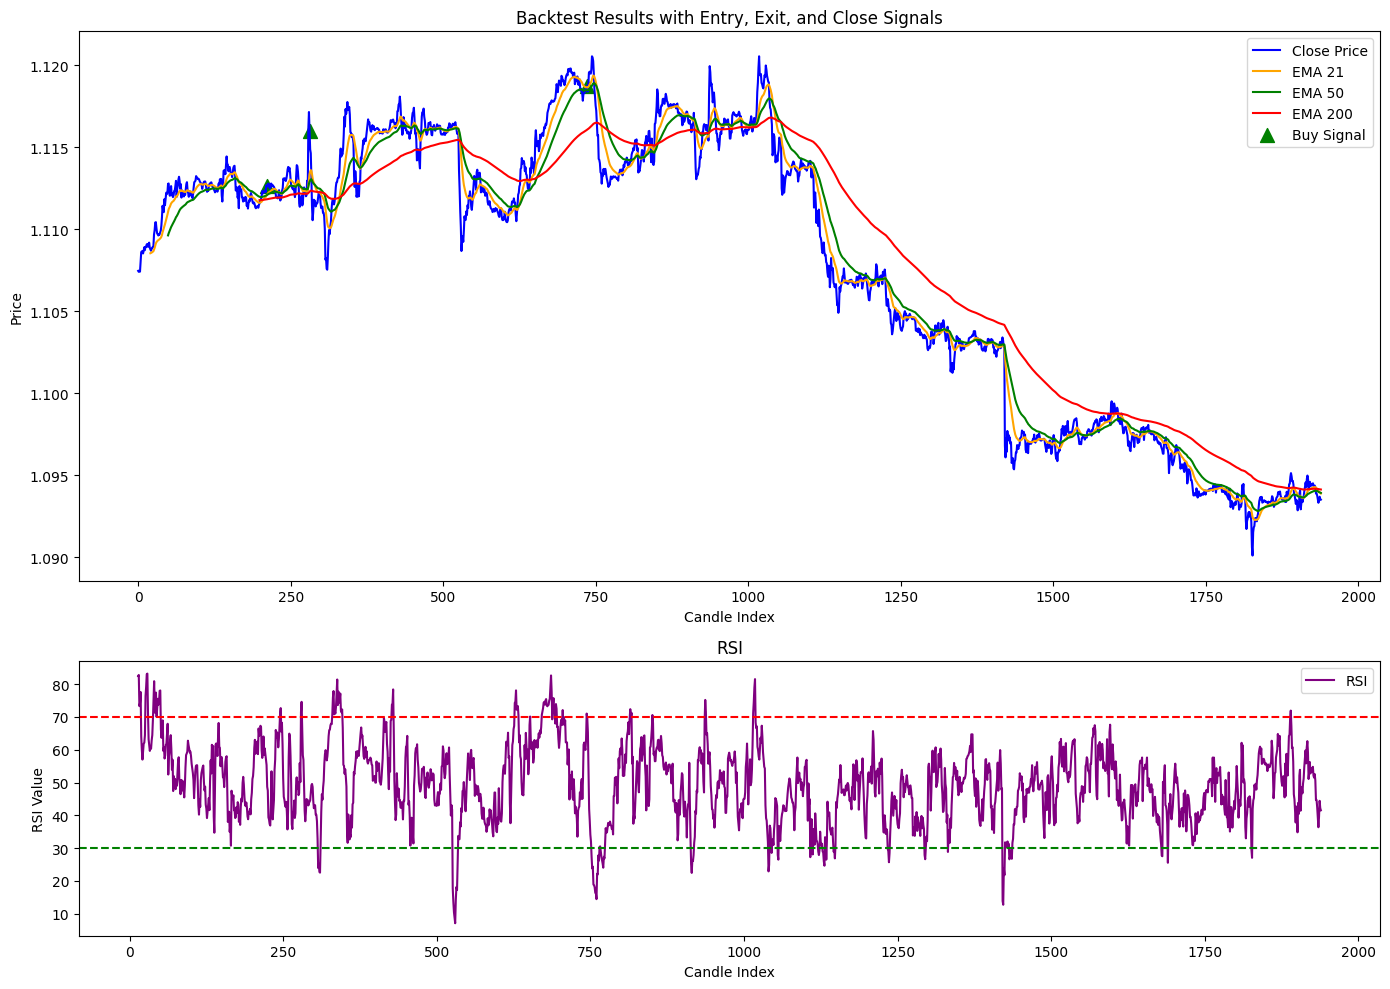

In [6]:
backtest.plot_results()